<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 10: Further Essential Techniques

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>   
    <li><a href='#broadcasting' style="color:black;">Broadcasting in PyTorch</a></li>
    <li><a href='#controlling_learning' style="color:black;">Gradient Flow and Parameter States</a></li>
    <ul>
    <li><a href='#controlling_learning_detach' style="color:black;">Detach: Stopping Gradient Flow</a></li> 
    <li><a href='#controlling_learning_modes' style="color:black;"> Gradient-Free Inference and Train/Eval Modes</a></li>        
    </ul>  
    <li><a href='#normalization' style="color:black;">Normalization in Deep Learning</a></li>   
    <ul>
    <li><a href='#normalization_input' style="color:black;">Input Normalization</a></li> 
    <li><a href='#normalization_batch' style="color:black;">Batch Normalization</a></li>        
    </ul>   
    <li><a href='#regularization' style="color:black;">Regularization in Deep Learning</a></li>   
    <ul>
    <li><a href='#regularization_weight_decay' style="color:black;">Weight Decay (L2 Regularization)</a></li> 
    <li><a href='#regularization_dropout' style="color:black;">Dropout</a></li>        
    </ul>            
    <li><a href='#custom_functions' style="color:black;">Custom Functions in PyTorch</a></li> 
    <li><a href='#exercise_bn_running_stats' style="color:#006064;"><strong>Exercise 1:</strong> Batch Normalization Running Statistics</a></li>  
    <li><a href='#exercise_dropout_masks' style="color:#006064;"><strong>Exercise 2:</strong> Visualizing Dropout Masks and Inverted Scaling</a></li>     
    <li><a href='#exercise_custom_losses' style="color:#006064;"><strong>Exercise 3:</strong> Learning a Convolution Kernel with Different Loss Functions</a></li>      
</ul>  

<a id='learn'></a> 
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">Overview and Learning Objectives</h2>

<p style="color:#E65100;">
This final unit brings together key PyTorch techniques such as broadcasting, gradient control, normalization, regularization, and custom objectives. It complements the concepts introduced in previous units by deepening the understanding of how PyTorch manages tensor operations, gradient flow, training stability, and flexible ways of defining objectives. Rather than introducing entirely new material, this unit enriches skills already encountered, highlighting connections and broadening perspectives. The learning objectives of this unit are as follows:
</p>

<ul style="color:#E65100;">
<li>Understand how <strong>broadcasting</strong> works in PyTorch and apply it in the context of <strong>batch processing</strong> to concisely and efficiently perform operations on tensors of different shapes.</li>  
<li>Gain control over gradient flow using <strong>detaching</strong> and <strong>freezing</strong>, reinforcing the understanding of PyTorch's autograd mechanism.</li>  
<li>Explore how <strong>normalization</strong> contributes to stable and efficient training, with a focus on both input normalization and batch normalization.</li>  
<li>Revisit <strong>regularization</strong> as a means to improve generalization, with awareness of methods such as weight decay and dropout that complement the training dynamics covered in earlier units.</li>  
<li>Define <strong>custom loss functions</strong> using standard PyTorch tensor operations, demonstrating the flexibility of autograd and encouraging creativity in research-oriented tasks.</li>  
</ul>  

<p style="color:#E65100;">
The unit includes three hands-on exercises:  
</p>
<ul style="color:#E65100;">
<li><a href="#exercise_bn_running_stats">Exercise 1</a>: Investigate how <strong>running statistics</strong> are maintained in batch normalization layers and what this means for training stability.</li>  
<li><a href="#exercise_dropout_masks">Exercise 2</a>: Visualize <strong>dropout masks</strong> in action and see how inverted scaling ensures consistent activation magnitudes between training and inference.</li>  
<li><a href="#exercise_custom_losses">Exercise 3</a>: Learn a convolution kernel under different <strong>customized loss functions</strong>, encouraging experimentation with PyTorch's flexible autograd system.</li>  
</ul>  

<p style="color:#E65100;">
For more details, see the <a href="https://pytorch.org/docs/stable/nn.html" target="_blank">PyTorch documentation on normalization, dropout, and loss functions</a>. 
</p>
</div>

In [1]:
# --- Standard libraries ---
import copy
import time

# --- Core scientific stack ---
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# --- Custom utilities (Unit 10) ---
from libpcpt.unit10 import (
    plot_data_boundary,
    plot_loss_curves,
    plot_regression_predictions,
    plot_regression_coefficients,
    plot_loss_matrix,
    plot_six_signals,
    exercise_bn_running_stats,
    exercise_dropout_masks,
    exercise_custom_losses
)

# --- Vectorized figures ---
%config InlineBackend.figure_formats = ['svg']

<a id='broadcasting'></a> 
## Broadcasting in PyTorch

Back in <a href="PCPT_03_tensor.html">Unit 3 (PyTorch Tensors)</a>, we learned how tensors are created, inspected, and reshaped. Those ideas now return as the foundation for understanding batch processing and broadcasting.  

- **Tensor attributes** such as `shape`, `size`, and `dim` helped us describe how data is arranged in memory. These attributes are especially important when distinguishing between single samples and collections of samples (mini-batches).  
- **Reshaping operations** like `.view()`, `.reshape()`, `.ravel()`, `.flatten()`, `.squeeze()`, and `.unsqueeze()` showed how to add, remove, flatten, or reorganize dimensions. Such operations are often needed when preparing data for models or aligning it with other tensors.  
- **Indexing, slicing, and transposition** introduced the flexibility of accessing and reordering tensor elements, a skill that becomes essential when working with batches of data.  
- **Reduction operations** such as `mean(dim=...)` or `sum(dim=...)` illustrated how computations can be applied along specific dimensions. Broadcasting extends this principle by letting PyTorch automatically align dimensions of different tensors for elementwise operations.

In practice, tensors rarely have the same shape. You might **add a bias vector** to each row of a matrix. You might also **scale each channel** in a batch of 1D signals (i.e., multiply each channel by its own scalar across all items and time steps). Or you might **normalize each sequence** by its own statistics (i.e., for each sample, subtract its mean and divide by its standard deviation along the time axis). In all these cases, you could write loops or tile arrays to force shapes to match. That approach is verbose, slow, and easy to get wrong. **Broadcasting** lets PyTorch perform these elementwise operations as if smaller tensors were stretched to the needed size, without making copies. Your code stays short, clear, and fast. Before we go into detail, let us look at three simple examples of the cases above.

In [2]:
# Broadcasting: Three typical examples

# Example 1: Add a bias vector to each row of a matrix: (B, D) + (D,)
X = torch.arange(1., 7.).view(2, 3)      # shape: (2, 3)
b = torch.tensor([1., 2., 3.])           # shape: (3,)
Y = X + b                                # (3,) -> behaves like (1, 3) -> (2, 3)
print("Example 1: Add a bias vector to each row of a matrix")
print("Shapes:   ", X.shape, "+", b.shape, "->", Y.shape)
print(Y)

# Example 2: Scale each channel in a batch of 1D signals: (B, C, T) * (C,)
X = torch.arange(1., 25.).view(2, 3, 4)  # shape: (2, 3, 4)
g = torch.tensor([1., 2., 3.])           # per-channel gains, (3,)
Y = X * g.view(1, 3, 1)                  # (3,) -> (1, 3, 1), broadcasts over B and T
print("\nExample 2: Scale each channel in a batch of 1D signals")
print("Shapes:   ", X.shape, "*", g.view(1, 3, 1).shape, "->", Y.shape)
print(Y)

# Example 3: Normalize each sequence by its own mean/std along time: (B, T)
seq = torch.arange(1., 11.).view(2, 5)   # shape: (2, 5)
mu  = seq.mean(dim=1, keepdim=True)      # (2, 1)
std = seq.std(dim=1, keepdim=True)       # (2, 1) 
seq_norm = (seq - mu) / std              # broadcasts over T
print("\nExample 3: Normalize each sequence by its own mean/std")
print("Shapes:   ", seq.shape, "->", seq_norm.shape)
print("means:", mu)
print("stds: ", std)
print(seq_norm)

Example 1: Add a bias vector to each row of a matrix
Shapes:    torch.Size([2, 3]) + torch.Size([3]) -> torch.Size([2, 3])
tensor([[2., 4., 6.],
        [5., 7., 9.]])

Example 2: Scale each channel in a batch of 1D signals
Shapes:    torch.Size([2, 3, 4]) * torch.Size([1, 3, 1]) -> torch.Size([2, 3, 4])
tensor([[[ 1.,  2.,  3.,  4.],
         [10., 12., 14., 16.],
         [27., 30., 33., 36.]],

        [[13., 14., 15., 16.],
         [34., 36., 38., 40.],
         [63., 66., 69., 72.]]])

Example 3: Normalize each sequence by its own mean/std
Shapes:    torch.Size([2, 5]) -> torch.Size([2, 5])
means: tensor([[3.],
        [8.]])
stds:  tensor([[1.5811],
        [1.5811]])
tensor([[-1.2649, -0.6325,  0.0000,  0.6325,  1.2649],
        [-1.2649, -0.6325,  0.0000,  0.6325,  1.2649]])


More formally, **broadcasting** is PyTorch's rule set for performing elementwise operations on tensors of different shapes by **virtually expanding** axes of size 1 or adding additional dimensions (without copying data). Concretely:

1) **Align from the right:** Compare shapes starting with the last dimension.  
2) **Compatibility:** two sizes are compatible if they are equal or one of them is `1`.  
3) **Pad with leading 1s:** If a tensor has fewer dimensions, treat missing leading dimensions as `1`.  
4) **Result shape:** For each dimension, take the larger size (after padding with leading 1s).  
5) **Virtual expansion:** Size-1 dimensions behave as repeated; during backprop, gradients over expanded dimensions are summed into the original size-1 dimension.

The following table provides typical examples of **compatible** and **incompatible** broadcasting cases. It lists the input shapes, whether broadcasting is possible, the resulting shape, and a brief comment or example use case.

<style>
/* Force left-aligned tables in classic HTML export */
table, th, td {
    text-align: left !important;
}
</style>

<table style="width:95%; border-collapse: collapse; margin-top: 10px; margin-bottom: 10px; table-layout: fixed;">
  <colgroup>
      <col style="width:15%;">
      <col style="width:15%;">
      <col style="width:15%;">
      <col style="width:15%;">
      <col style="width:40%;">
  </colgroup>
  <thead>
      <tr style="background-color: #e3e3e3; text-align: left;">
          <th style="border: 1px solid #ccc; padding: 6px;">A shape</th>
          <th style="border: 1px solid #ccc; padding: 6px;">B shape</th>
          <th style="border: 1px solid #ccc; padding: 6px;">Compatible</th>
          <th style="border: 1px solid #ccc; padding: 6px;">Result shape</th>
          <th style="border: 1px solid #ccc; padding: 6px;">Comment / Example use case</th>
      </tr>
  </thead>
  <tbody>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, D)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(1, D)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Yes</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, D)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Bias per feature; leading <code>1</code> &rarr; <code>B</code>.</td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, D)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(D,)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Yes</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, D)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(D,)</code> behaves like <code>(1, D)</code>.</td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(1, C, 1)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Yes</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Per-channel scaling across <code>B</code> and <code>T</code>.</td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(C, 1)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Yes</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(C, 1)</code> is treated as <code>(1, C, 1)</code>.</td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>()</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Yes</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Scalar broadcasts to all dims.</td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, 1, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(1, C, 1)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Yes</td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">Size-1 dims expand to other's dims (<code>1</code> &rarr; <code>B</code>, <code>1</code> &rarr; <code>T</code>).</td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(2, D)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(3, D)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">No</td>
          <td style="border: 1px solid #ccc; padding: 6px;">&mdash;</td>
          <td style="border: 1px solid #ccc; padding: 6px;">Leading dims <code>2</code> vs. <code>3</code>; neither is <code>1</code>.</td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, 2)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(B, C, 4)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">No</td>
          <td style="border: 1px solid #ccc; padding: 6px;">&mdash;</td>
          <td style="border: 1px solid #ccc; padding: 6px;">Last dim <code>2</code> vs. <code>4</code>; neither is <code>1</code>.</td>
      </tr>
      <tr style="background-color: white; transition: none;">
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(3, 2, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;"><code>(3, T)</code></td>
          <td style="border: 1px solid #ccc; padding: 6px;">No</td>
          <td style="border: 1px solid #ccc; padding: 6px;">&mdash;</td>
          <td style="border: 1px solid #ccc; padding: 6px;">Pad <code>(3, T)</code> &rarr; <code>(1, 3, T)</code>; middle dims <code>2</code> vs. <code>3</code> mismatch.</td>
      </tr>
  </tbody>
</table>

We have seen that PyTorch can **broadcast** automatically (for example in `X + b`). If we want to make this broadcasting step explicit, we can use two operations:

* `expand` pretends to stretch size-1 dimensions **without actually copying data**. It returns a new view that reuses the same underlying storage, so it is memory-efficient and usually fast.
* `repeat` really **copies** the data and tiles it, creating a larger tensor in memory. This uses more memory and is often slower, but the copies are fully independent.

Numerically, `X.expand(...) + b` and `X.repeat(...) + b` give the same result, but their memory behavior is very different. This leads to an important caveat: you should **not** use `expand` if you plan to modify the expanded tensor **in place** (for example with `X += 1`), because many positions in the expanded view refer to the same data underneath. Changing one element would unintentionally change others. In such cases, `repeat` is the safer option, since it creates separate copies that can be changed independently or stored as they are.

In the small experiment below, we compare these two approaches: we check that the numerical outputs match, inspect how storage is shared or copied, estimate the memory required, and measure the time needed both to construct the expanded/repeated tensors and to perform the addition.

In [3]:
# Broadcasting (expand) vs. repeat: same result, different mechanics and speed

# Setup
N, D = 5000, 1000                       # large enough to see timing/memory effects
X = torch.arange(N*D, dtype=torch.float32).view(N, D)
b = torch.linspace(0.0, 1.0, D, dtype=torch.float32)

# Conceptual operands
b_exp = b.unsqueeze(0).expand(N, -1)    # view: no copy
b_rep = b.unsqueeze(0).repeat(N, 1)     # copy: materialized (N,D)

# Sanity: same math
Y1 = X + b_exp
Y2 = X + b_rep
print("Equal results:", torch.allclose(Y1, Y2))

# Storage behavior (expand shares storage; repeat allocates new)
print("b_exp shares storage with b:", b_exp.data_ptr() == b.data_ptr())
print("b_rep shares storage with b:", b_rep.data_ptr() == b.data_ptr())

# Rough memory footprint for the operand added to X
bytes_per_element = b.element_size()
storage_b     = b.numel()     * bytes_per_element / 1e6
storage_b_rep = b_rep.numel() * bytes_per_element / 1e6
print(f"numel(b)     = {b.numel():8}  (about {storage_b:4.3f} MB)")
print(f"numel(b_exp) = {b_exp.numel():8}  (about {storage_b:4.3f} MB; "
      f"no extra storage)")
print(f"numel(b_rep) = {b_rep.numel():8}  (about {storage_b_rep:4.1f} MB)")

# Timing helpers
def bench(fn, iters=10, warmup=2):
    for _ in range(warmup):
        fn()
    times = []
    for _ in range(iters):
        t0 = time.perf_counter()
        fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return sum(times) / len(times)

with torch.no_grad():
    # Build-time: expanding a view vs. making a full copy
    t_build_exp = bench(lambda: b.unsqueeze(0).expand(N, -1))
    t_build_rep = bench(lambda: b.unsqueeze(0).repeat(N, 1))
    # Add-time: using expanded view vs. repeated copy
    t_add_exp   = bench(lambda: (X + b.unsqueeze(0).expand(N, -1)).sum().item())
    t_add_rep   = bench(lambda: (X + b.unsqueeze(0).repeat(N, 1)).sum().item())

print(f"\nBuild with b_exp: {t_build_exp*1e3:6.4f} ms/run")
print(f"Build with b_rep: {t_build_rep*1e3:6.4f} ms/run")
print(f"Add with b_exp:   {t_add_exp*1e3:6.4f} ms/run")
print(f"Add with b_rep:   {t_add_rep*1e3:6.4f} ms/run")

Equal results: True
b_exp shares storage with b: True
b_rep shares storage with b: False
numel(b)     =     1000  (about 0.004 MB)
numel(b_exp) =  5000000  (about 0.004 MB; no extra storage)
numel(b_rep) =  5000000  (about 20.0 MB)



Build with b_exp: 0.0716 ms/run
Build with b_rep: 0.6128 ms/run
Add with b_exp:   1.9526 ms/run
Add with b_rep:   10.9993 ms/run


<a id='controlling_learning'></a> 
## Gradient Flow and Parameter States

In earlier PCPT units, we built and trained small neural networks. We updated their parameters with gradient descent, and afterwards we evaluated the trained models without changing them anymore. This naturally raises a simple but important question: **when does the model actually learn, and what part of the model is being changed during learning?** In PyTorch, this learning behavior is controlled by three closely related mechanisms:

- **Gradient tracking (autograd):** Records tensor operations to build a computation graph. Backpropagation uses this graph to compute gradients. Use `.detach()` to stop gradients for an existing tensor, and `with torch.no_grad()` (or `with torch.inference_mode()`) to disable tracking inside a code block.  
- **Parameter state:** Marks each parameter as **trainable** (`requires_grad=True`) or **frozen** (`requires_grad=False`). Only trainable parameters receive gradients and optimizer updates.  
- **Model mode:** Switches between **training** (`model.train()`) and **evaluation** (`model.eval()`), affecting layers with state or randomness (e.g., `BatchNorm` running statistics, `Dropout` on/off; these layers will be discussed later in this unit).

 In the following, we review and connect these ideas. We show how to **detach** values to stop gradient flow, **freeze** selected parameters, run **inference without gradients**, and use **train/eval modes** to control layer behavior. Although PCPT remains CPU-only and lightweight, the same principles generalize to larger architectures. The aim is to develop a clear understanding of how to control the learning, so experiments are predictable, efficient, and easy to debug.

<a id='controlling_learning_detach'></a> 
### Detach: Stopping Gradient Flow

Sometimes one needs a tensor's value for the forward pass, but not its influence on learning. The method `.detach()` provides this: it returns a tensor with the **same numbers**, but autograd treats it as a **constant**. Gradients stop at that point and do not flow back through the computation that produced it.

A helpful way to think of `.detach()` is: **keep the value, stop the learning**. The numbers stay the same, but autograd forgets how they were computed and treats them as constants, so no gradients flow through them. For example, we can reuse a model output as plain data without changing the part that produced it, or detach features before saving or plotting so PyTorch stops tracking their history and saves memory. For long sequences, we often process data in smaller chunks and `detach()` the hidden state between chunks so gradients do not go back through the whole past. This makes training faster, uses less memory, and prevents gradients from growing out of control.

A detached tensor **shares memory** with the original, so changing one also changes the other. If modification is intended, one can use `clone().detach()` to obtain an independent copy. Also note that `.detach()` acts on **one** existing tensor, while `with torch.no_grad()` or `with torch.inference_mode()` turns gradient tracking off for **all** computations created inside the block.

In the example below, we compute a small two-branch loss twice, once with the second branch detached and once without. The comparison shows how detaching removes that branch’s contribution to the parameter's gradient.

In [4]:
# Toy PyTorch example: Detach stops gradient flow through a value.
def run_case_grad(detach, w, x):
    """
    Compute grad wrt w for a 2-branch loss:
      branch A: uses w -> gradients flow
      branch B: uses w or w.detach() depending on "detach"
    Returns the scalar gradient on w.
    Note: We reset w.grad so results do not accumulate across calls.
    """
    w.grad = None              # Reset gradient
    a = w * x                  # Branch A: gradient flows through w 
    if detach:
        b = w.detach() * x     # Branch B: same value, no gradients
    else:
        b = w * x              # Branch B: gradient flows through w 
        
    loss_a = a**2              # Loss for branch A, d/dw(loss_a) = 2*w*x*x
    loss_b = b**2              # Loss for branch B, d/dw(loss_b) = 0 if w is detached
    loss = loss_a + loss_b     # Total loss as sum
    loss.backward()            # Backprop computes w.grad
    return loss.item(), w.grad.item()    

w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)

# A + B contribute
loss_both, grad_both = run_case_grad(False, w, x)
print(f"detach = False -> loss = {loss_both:4.1f}, grad = {grad_both:4.1f}")

# Only A contributes (B detached)
loss_det, grad_det = run_case_grad(True, w, x)
print(f"detach = True  -> loss = {loss_det:4.1f}, grad = {grad_det:4.1f}")

detach = False -> loss = 72.0, grad = 72.0
detach = True  -> loss = 72.0, grad = 36.0


### Gradient-Free Inference and Train/Eval Modes

Back in <a href="PCPT_04_grad.html">Unit 4 (Automatic Differentiation)</a>, we learned that gradient tracking allows `backward()` to compute how changes in the parameters affect a loss. However, there are many situations where we do **not need** gradients. Typical examples are prediction (inference), validation, parameter initialization in a module's `__init__`, or parts of a model that are frozen and should no longer learn. In these cases, we can wrap the relevant code in `with torch.no_grad():`. Inside this block, PyTorch performs the same computations and produces the same numerical results, but it **does not build a computation graph**. This reduces memory usage and can make the code run faster. The effect is temporary: it applies only inside the block and does not change whether a parameter is marked as trainable through its `requires_grad` flag.

The method `torch.inference_mode()` serves the same goal but is stricter and often faster than `torch.no_grad()`. Both disable gradient tracking inside their block. Inference mode adds extra optimizations (e.g., reusing tensor storage when possible), improving memory use and speed. With `torch.no_grad()`, one can re-enable autograd inside the block; with `torch.inference_mode()`, autograd stays off for the entire block. For most inference tasks, outputs are the same; differences are mainly internal efficiency and safety. In summary, use `torch.inference_mode()` for pure inference/evaluation where gradients are never needed, and use `torch.no_grad()` for a temporary, flexible pause on gradient tracking.

Complementing gradient-control contexts, `model.train()` and `model.eval()` control **layer behavior** during the forward pass. In training mode, layers that use randomness or running statistics behave accordingly (e.g., `Dropout` on, `BatchNorm` updates running estimates). In evaluation mode, these layers become deterministic (`Dropout` off; `BatchNorm` uses stored statistics). This switch does not freeze parameters and does not turn off autograd; it only changes how such layers act. Thus, gradient-control contexts and mode switches serve different purposes and are often used together:

- **Training:** call `model.train()` and use normal gradient tracking.  
- **Validation/Test/Inference:** call `model.eval()` and wrap in a no-gradient context, e.g. `with torch.no_grad(): y = model(x)` 
- **Freezing is separate:** set `requires_grad=False` on parameters that should not be updated.

Runnable toy examples showing how `model.train()` and `model.eval()` affect layers such as `Dropout` and `BatchNorm` will appear later in this unit.

<a id="normalization"></a>
## Normalization in Deep Learning

When numbers come from different sources or use different units, it is often necessary to bring them onto a common scale so that comparisons are meaningful. This idea appears in many fields: pixel intensities in images are scaled to a fixed range for consistent processing, variables in statistics are centered to make effects easier to interpret, and measurements are standardized so algorithms are not biased toward features with the largest units. In audio and music processing, for example, signal energy or loudness is often normalized before feeding data into machine learning models. This preprocessing step is called **data normalization**, and it involves transforming raw features into a standardized scale or distribution. Common strategies include mapping values into a **fixed range** (e.g., `[0, 1]`) or standardizing them to have **zero mean** and **unit variance**. Normalization makes features comparable, which in turn improves efficiency, stability, and overall performance in machine learning. Normalization is a tool to reveal structure: after rescaling, patterns are easier to detect, models converge more reliably, and results become more reproducible.  

When moving from general data science and machine learning to **deep learning**, the same principles of normalization apply but with an extended focus. Neural networks benefit not only from normalized inputs but also from normalization techniques that operate inside the model. In other words, both the raw data fed into the network and the internal activations produced during training can vary in scale and distribution, and both can be stabilized through normalization. Two common forms of normalization in deep learning are:

- **Input normalization (before the model):** For example, dividing image pixel intensities by 255 to bring them into `[0, 1]`, or subtracting a mean and dividing by a standard deviation so features are on comparable scales. This keeps input ranges reasonable and makes optimization smoother.  
- **Activation normalization (inside the model):** Layers such as batch normalization (`BatchNorm`) or layer normalization (`LayerNorm`) normalize intermediate activations during the forward pass. This stabilizes and accelerates training by reducing fluctuations in the internal distributions of activations.  

In the following, we keep things lightweight and do not aim for a comprehensive treatment, given the many ways normalization can be applied. We introduce **input normalization** as an example of model-independent normalization and **batch normalization** as an example of normalization inside a network, illustrated with a few toy examples to show how these concepts may be applied.  

<a id="normalization_input"></a>
### Input Normalization

Having introduced normalization in general terms, we now turn to **input normalization**, the simplest and most widely used form. Input normalization is applied **before** the data enters the model and ensures that different features are brought onto comparable scales. This prevents features with large numerical ranges from dominating the learning process and helps the optimizer move more steadily toward a good solution. Let $\mathbf{x} = (x_1, \dots, x_D)^\top \in \mathbb{R}^D$ denote a $D$-dimensional feature vector that serves as input to a model. We will use $\tilde{\mathbf{x}}$ to denote a normalized version of $\mathbf{x}$. Common normalization strategies include:  

- **Min–max scaling:** Rescale each component of $\mathbf{x}$ to a fixed interval such as $[0,1]$. Let $x_{\min}$ and $x_{\max}$ denote the minimum and maximum values of the feature:  
  $$
  \tilde{\mathbf{x}} = \frac{\mathbf{x} - x_{\min}}{x_{\max} - x_{\min}}.
  $$  
  A common example is dividing image pixel values (originally in $[0,255]$) by 255 so they fall into $[0,1]$. For audio waveforms, raw samples representing air-pressure oscillations are often scaled to lie within $[-1,1]$.  

- **Standardization:** Subtract the mean and divide by the standard deviation. With  
  $$
  \mu = \frac{1}{D}\sum_{d=1}^D x_d
  \quad  \mathrm{and} \quad
  \sigma = \Big( \frac{1}{D}\sum_{d=1}^D (x_d - \mu)^2 \Big)^{1/2},
  $$  
  the standardized vector is  
  $$
  \tilde{\mathbf{x}} = \frac{\mathbf{x} - \mu}{\sigma}.
  $$  
  For example, if two microphones record the same music performance with different gain settings, standardization removes offset and scale differences so that the signals can be compared on a common basis.  

- **Norm-based normalization:** Scale the entire vector $\mathbf{x}$ so that its $\ell^p$-norm becomes 1. The $\ell^p$-norm is defined as  
  $$
  \|\mathbf{x}\|_p = \Big( \sum_{i=1}^D |x_i|^p \Big)^{1/p}, \quad 1 \leq p < \infty,
  $$  
  with $p=1$ ($\ell^1$-norm, sum of absolute values) and $p=2$ ($\ell^2$-norm, Euclidean length) being most common. The normalized vector is then  
  $$
  \tilde{\mathbf{x}} = \frac{\mathbf{x}}{\|\mathbf{x}\|_p}, \quad 1 \leq p < \infty.
  $$  
  This is useful when the **direction** of $\mathbf{x}$ is more important than its magnitude. For example, in audio analysis one may compare spectral shapes, where the relative distribution of energy across frequencies is key for distinguishing timbre or instrument type, regardless of overall intensity.  

- **Domain-specific normalization:** Not all normalization is purely mathematical. In some fields, conventions tied to perception or standards are used. For example, in natural language processing, text may be normalized by converting all characters to lowercase or removing accents (e.g., *Café* &rarr; *cafe*). This may reduce irrelevant variation while making inputs more comparable.  

These strategies all share the same goal: to keep input values within a reasonable and consistent range so that learning becomes more efficient, stable, and reliable. In practice, this has a direct effect on optimization. When features vary widely in scale, gradient updates are uneven and the optimizer tends to zigzag across the loss surface, making convergence slower and less predictable. Normalization alleviates this by transforming the problem into a **better conditioned** one: the loss contours become more balanced and well-aligned, so gradient-based methods can follow a straighter path toward the optimum. In other words, standardization not only improves accuracy but also makes learning faster and more stable. 

To see this effect in practice, we now turn to a **small PyTorch example**. We generate a 2D toy dataset with poorly scaled features and train the same simple classifier twice: once on the **raw inputs** and once on **standardized inputs** (zero mean and unit variance per feature). By comparing the learned decision boundaries for different numbers of training epochs, you can clearly see how standardization improves optimization, in particular how it leads to much faster and more robust convergence.

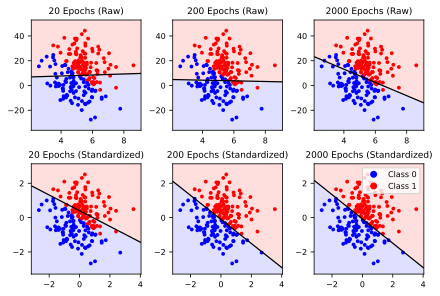

In [5]:
# Toy PyTorch example: Why input standardization matters
torch.manual_seed(0)

# Toy data (2-D, poorly scaled features)
N = 200
x1 = torch.randn(N, 1) + 5.2              # small variance, shifted
x2 = 13 * torch.randn(N, 1) + 10          # large variance, shifted
X  = torch.cat([x1, x2], 1)               # shape (N, 2)
y  = (x1 - 6 + 0.1 * x2 > 0).float()      # defining reference decision bound

# Input standardization (feature-wise)
mu, sigma = X.mean(0, keepdim=True), X.std(0, keepdim=True)
eps = 1e-6
X_std = (X - mu) / (sigma + eps)          # eps avoids division by zero

# Tiny training loop (logistic regression)
def train(X, y, epochs=200, lr=0.1, seed=0):
    """Train a 2D logistic regressor with BCE-with-logits."""
    torch.manual_seed(seed)               # fair comparison: same init per run
    model = nn.Linear(2, 1)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss_fn(model(X), y).backward()
        opt.step()
    return model

# Run experiments: raw vs. standardized, few vs. many epochs
epochs_list = [20, 200, 2000]
fig, axs = plt.subplots(2, 3, figsize=(5.9, 4), constrained_layout=True)

for col, epochs in enumerate(epochs_list):
    # same seed within a column -> isolates effect of normalization/epochs
    model_raw = train(X,     y, epochs=epochs, lr=0.1, seed=col)
    model_std = train(X_std, y, epochs=epochs, lr=0.1, seed=col)

    plot_data_boundary(axs[0, col], model_raw, X, y, f"{epochs} Epochs (Raw)")
    plot_data_boundary(axs[1, col], model_std, X_std, y, 
                       f"{epochs} Epochs (Standardized)", add_legend=(col==2))
plt.show()

<a id="normalization_batch"></a>
### Batch Normalization

While input normalization ensures that features enter a model on comparable scales, it does not control how internal **activations** behave as they propagate through deep networks. During training, the distribution of activations can shift over time (sometimes called **internal covariate shift**), making optimization more difficult. **Batch normalization (BN)** was introduced as a remedy: it normalizes activations **inside** the network, layer by layer, using statistics computed over each mini-batch of data. This stabilizes learning, allows higher learning rates, and often improves generalization. Let a mini-batch be denoted by  

$$
\mathcal{B} = \{\mathbf{x}^1, \ldots, \mathbf{x}^B\},
$$  

where each sample is represented by a feature vector  

$$
\mathbf{x}^b = (x^b_1, \dots, x^b_D)^\top \in \mathbb{R}^D, 
\qquad b \in \{1, \dots, B\}.
$$  

Here, $x^b_d$ denotes the $d$-th feature of the $b$-th sample. Opposed to input normalization, batch normalization operates **per feature dimension** $d \in \{1, \dots, D\}$ across the mini-batch. To this end, one computes the mean and variance for each feature dimension:  

$$
\mu_d^{\mathcal{B}} = \frac{1}{B} \sum_{b=1}^B x^b_d,
\qquad
(\sigma_d^{\mathcal{B}})^2 = \frac{1}{B} \sum_{b=1}^B \big(x^b_d - \mu_d^{\mathcal{B}}\big)^2.
$$  

Then each feature component is centered and scaled:  

$$
\tilde{x}^b_d = \frac{x^b_d - \mu_d^{\mathcal{B}}}{\sqrt{(\sigma_d^{\mathcal{B}})^2 + \varepsilon}},
$$  

where $\varepsilon > 0$ is a small constant for numerical stability. After this step, each feature dimension across the mini-batch has (approximately) zero mean and unit variance. 

Furthermore, batch normalization introduces two **learnable parameters** per feature: a scale $\gamma_d$ and a shift $\beta_d$. The normalized activations are adjusted as  

$$
y^b_d = \gamma_d \, \tilde{x}^b_d + \beta_d.
$$  

This design prevents the network from being overly constrained by zero-mean, unit-variance activations: $\gamma_d$ and $\beta_d$ restore flexibility, so training remains stable while the model retains full representational power. These parameters are updated just like all other trainable weights, via gradient descent during backpropagation. In short: BN normalizes for **stability**, $\gamma_d$ and $\beta_d$ restore **expressiveness**.

To illustrate the effect of batch normalization, we continue with our previous **PyTorch toy example** for binary classification on a 2D dataset with poorly scaled features. We now compare the training behavior of two simple MLP models:

- A three-layer MLP with two ReLU activations, **without** batch normalization.  
- A corresponding MLP where **batch normalization layers** are inserted before each ReLU activation.

This side-by-side comparison shows how batch normalization can stabilize training, support faster convergence, and make learning more robust.

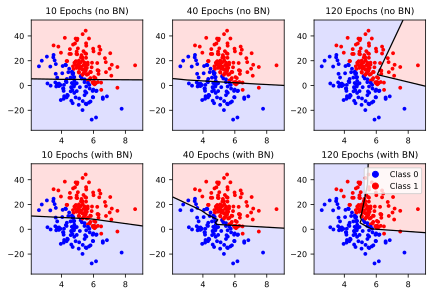

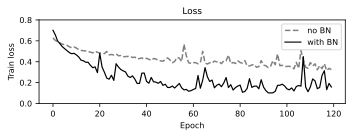

In [6]:
# Toy PyTorch example: Why BatchNorm helps inside the network
torch.manual_seed(0)

# Toy data (2-D, poorly scaled features)
N = 200
x1 = torch.randn(N, 1) + 5.2              # small variance, shifted
x2 = 13 * torch.randn(N, 1) + 10          # large variance, shifted
X  = torch.cat([x1, x2], 1)               # shape (N, 2)
y  = (x1 - 6 + 0.1 * x2 > 0).float()      # defining reference decision bound

# MLP models
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, num_classes=1, with_bn=False):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim) if with_bn else nn.Identity(), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2) if with_bn else nn.Identity(), 
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, num_classes)  # logits
        )
    def forward(self, x):
        return self.net(x)

# Training loop returning model and loss trajectory
def train_model(X, y, epochs=100, lr=0.1, seed=0, with_bn=False, batch_size=64):
    torch.manual_seed(seed)
    model = SimpleMLP(input_dim=2, num_classes=1, with_bn=with_bn)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    # Make a simple dataset/loader for mini-batches (BN needs batches)
    dataset = torch.utils.data.TensorDataset(X, y)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []
    model.train()
    for _ in range(epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            logits = model(xb).view(-1, 1)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * xb.size(0)
        losses.append(epoch_loss / len(dataset))
    return model, losses

# Run experiments: deep MLP, raw inputs, no-BN vs. BN, various epochs
epochs_list = [10, 40, 120]
fig, axs = plt.subplots(2, 3, figsize=(5.9, 4), constrained_layout=True)

for col, ep in enumerate(epochs_list):
    # same seed for all settings -> isolates effect of no-BN vs. BN
    model_no_bn, losses_no_bn    = train_model(X, y, epochs=ep, with_bn=False)
    model_with_bn,  losses_w_bn  = train_model(X, y, epochs=ep, with_bn=True)
    all_losses = np.zeros((2, ep))
    all_losses[0, :] = losses_no_bn
    all_losses[1, :] = losses_w_bn
    plot_data_boundary(axs[0, col], model_no_bn,   X, y, f"{ep} Epochs (no BN)")
    plot_data_boundary(axs[1, col], model_with_bn, X, y, f"{ep} Epochs (with BN)", 
                       add_legend=(col==2))
plt.show()

# Loss curves (only for last epoch setting)
plot_loss_curves(all_losses, epochs_list[-1], labels=("no BN", "with BN"), 
                 figsize=(5,2), ylim=[0, 0.8])

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> In most deep networks, batch normalization is applied <strong>after</strong> the linear or convolution layer and <strong>before</strong> the activation function. In other words, batch normalization normalizes the linear output, keeping these values in a reasonable range and roughly centered around zero before they are passed into the nonlinear activation function. For example, with a ReLU activation, this helps the unit behave well: some values are positive (and pass through), and some are negative (and are set to zero). If the values going into ReLU are poorly scaled, many of them may be strongly negative all the time, causing the neuron to always output zero and stop learning. This situation is often referred to as a <strong>dead ReLU</strong>. By normalizing the values <em>before</em> the activation, batch normalization reduces this problem, improves gradient flow, and makes training more stable.
</p>
</div>

### Running Statistics and Modes

To conclude, let us look a bit closer at how **batch normalization layers** behave in practice. Rather than recomputing batch statistics from scratch at every forward pass, BN maintains **running statistics** (exponential moving averages of the mean and variance) during training. These running values approximate dataset-wide statistics and allow the model to behave consistently once training is complete. This distinction explains the importance of switching between modes:

* In **training mode** using `model.train()`, BN computes the mean $\mu_d^{\mathcal{B}}$ and variance $(\sigma_d^{\mathcal{B}})^2$ from the current mini-batch and simultaneously updates the running averages.
* In **evaluation mode** using `model.eval()`, the mini-batch statistics are no longer used. Instead, the **stored running mean and variance** are applied:
$$
  \tilde{x}^b_d = \frac{x^b_d - \mu_d^{\text{run}}}{\sqrt{(\sigma_d^{\text{run}})^2 + \varepsilon}}.
$$

This ensures deterministic and stable inference, independent of the specific mini-batch. Without this mechanism, predictions would fluctuate depending on the random composition of the evaluation batch.

Continuing with our trained model `model_with_bn`, the next code cell illustrates this behavior:
* We first inspect the BN layers, printing scale ($\gamma$), shift ($\beta$), and running statistics.
* We then compare outputs in train vs. eval mode, showing that in training mode results depend on the mini-batch, while in evaluation mode they remain fixed.

In [7]:
# Show the BN-based model architecture
print("=== model_with_bn ===")
print(model_with_bn)

# Inspect BatchNorm parameters and running statistics
print("\n=== BatchNorm layers: parameters and running stats ===")
for name, module in model_with_bn.named_modules():
    if isinstance(module, nn.BatchNorm1d):
        print(f"\nLayer: {name}")
        print("  gamma (weight):", module.weight.data.detach().numpy().round(2))
        print("  beta  (bias):  ", module.bias.data.detach().numpy().round(2))
        print("  running mean:  ", module.running_mean.detach().numpy().round(2))
        print("  running var:   ", module.running_var.detach().numpy().round(2))

# Train vs. Eval behavior on the same batches (sizes 4, 8, 12)
batch_sizes = [2, 4, 8]
train_outputs, eval_outputs = {}, {}

# Snapshot the model *including* BN running stats
base_state = copy.deepcopy(model_with_bn.state_dict())

def fmt(arr):
    return "[" + " ".join(f"{v:5.2f}" for v in arr) + "]"

for k in batch_sizes:
    xb = X[:k]
    
    # TRAIN mode: forward uses batch statistics and updates running statistics
    model_with_bn.load_state_dict(base_state)
    model_with_bn.train()
    with torch.no_grad():
        out_train = torch.sigmoid(model_with_bn(xb)).squeeze().numpy()
    train_outputs[k] = out_train
    
   # EVAL mode: forward uses the stored running statistics
    model_with_bn.load_state_dict(base_state)
    model_with_bn.eval()
    with torch.no_grad():
        out_eval = torch.sigmoid(model_with_bn(xb)).squeeze().numpy()
    eval_outputs[k] = out_eval

print("\n=== Network output in TRAIN mode (batch stats; running stats updated) ===")
# Outputs change with batch size, because BN uses per-batch mean/variance
for k in batch_sizes:
    print(f"Batch size {k:2d}:", fmt(train_outputs[k]))

print("\n=== Network output in EVAL mode (fixed running stats; independent of batch) ===")
# Outputs stay consistent across batch sizes, because BN uses stored running mean/var
for k in batch_sizes:
    print(f"Batch size {k:2d}:", fmt(eval_outputs[k]))

=== model_with_bn ===
SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=4, bias=True)
    (4): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=4, out_features=1, bias=True)
  )
)

=== BatchNorm layers: parameters and running stats ===

Layer: net.1
  gamma (weight): [0.9  1.18 0.98 0.92 0.93 1.05 1.01 0.99]
  beta  (bias):   [-0.15  0.2  -0.01  0.11 -0.07  0.08  0.79 -0.02]
  running mean:   [  4.04 -10.72   3.23   5.87   8.61  -2.32  -2.5  -14.29]
  running var:    [ 25.56  93.83  16.33  42.84  97.75   5.43  75.78 263.01]

Layer: net.4
  gamma (weight): [1.31 1.21 1.74 1.5 ]
  beta  (bias):   [0.47 0.2  0.74 0.58]
  running mean:   [-0.19 -0.04  0.54 -0.73]
  running var:    [0.22 0.08 0.33 0.24]

=== Network output in TRAIN m

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> A common surprise with batch normalization is that a model can achieve a <strong>low training loss</strong> but show <strong>unstable decision boundaries</strong> when switched to evaluation mode. The reason is that BN behaves differently in the two phases. In training mode it normalizes activations using the mean and variance of the current mini-batch while also updating running averages of these statistics. The training loss looks fine because it is computed under the batch statistics. In evaluation mode BN ignores the current batch and relies only on the stored running averages. If these <strong>running values have not yet converged</strong>, for example after few epochs or with small batches, they may poorly reflect the data distribution and cause inconsistent outputs. In short, the phenomenon results from the <strong>mismatch</strong> between <strong>accurate batch statistics</strong> during training and <strong>imperfect running statistics</strong> during evaluation.
</p>
</div>

<a id="regularization"></a>
## Regularization in Deep Learning

As models become more powerful and flexible, they also become more vulnerable to **overfitting**, meaning they may learn noise or irrelevant details in the training data instead of capturing the underlying structure. This challenge is not unique to deep learning; in fact, it has been central to statistics and machine learning for decades. **Regularization** is best understood not as a single technique, but as a **general strategy**: deliberately adding constraints, biases, or sources of simplicity that prevent a model from exploiting its full flexibility. It may seem counterintuitive, but by slightly limiting what the model can do, we often make it more capable, more stable in training, and more reliable when faced with unseen data.

Looking back at the previous units, we have already met some forms of regularization. In <a href="PCPT_08_training.html">Unit 8 (Training Dynamics)</a>, splitting data into **train, validation, and test sets** ensured fair evaluation, while **early stopping** prevented the model from memorizing irrelevant details. In <a href="PCPT_09_recursion.html">Unit 9 (Recursion and RNNs)</a>, we addressed class imbalance using strategies such as **target smoothing** and **class weighting** to prevent the model from overfitting to the majority class. Even in <a href="PCPT_07_classification.html">Unit 7 (Classification)</a>, **data augmentation** acted as a regularizer by making models robust to variations in the input data. These examples show that regularization is already woven into many of the techniques we have studied. Common regularization strategies in deep learning include:

* **Early stopping** stops training when validation loss starts to increase, preventing the model from memorizing irrelevant details.
* **Learning rate scheduling** reduces the learning rate during training, encouraging convergence to more stable solutions.
* **Data augmentation** enlarges the dataset by perturbing inputs (e.g., shifts, noise, pitch changes) so the model becomes more robust.
* **Weight constraints and sparsity** limit the size or density of parameters (e.g., max-norm or L1 penalties), reducing complexity.
* **Stochasticity in training** uses mini-batch sampling and shuffling to inject variability that naturally discourages overfitting.
* **Weight decay (L2 regularization)** penalizes large parameter values, keeping solutions simpler.
* **Dropout** randomly deactivates units during training so the network does not rely too heavily on individual connections.

In practice, deep learning frameworks such as PyTorch provide many tools for regularization. Among them, two stand out as especially central: **weight decay** and **dropout**. In the following, we will explore these two approaches in more detail, both conceptually and with simple PyTorch examples.

<a id="regularization_weight_decay"></a>
### Weight Decay (L2 Regularization)

Having introduced regularization in general terms, we now turn to **weight decay**, also known as **L2 regularization**, one of the simplest and most widely used techniques. Weight decay is applied **during training** and encourages the model's parameters to remain small by adding a penalty proportional to their squared values. Imagine a network with very **large weights**: even a tiny change in the input can then produce an excessively large change in the output. This makes the model unstable and more likely to memorize noise or irrelevant details from the training data. By keeping the weights small, weight decay smooths out the model's response, leading to decision boundaries that are simpler and less sensitive to random fluctuations. In this way, the model trades a bit of flexibility for much better **generalization** to unseen data.  

Formally, let $\mathbf{w} \in \mathbb{R}^P$ denote the vector of all model parameters. A standard loss function $\mathcal{L}_{\text{task}}(\mathbf{w})$, such as cross-entropy or mean squared error, is extended by an additional penalty term: 

$$
\mathcal{L}_{\text{total}}(\mathbf{w}) = \mathcal{L}_{\text{task}}(\mathbf{w}) + \lambda \, \|\mathbf{w}\|_2^2,
$$  

where $\|\mathbf{w}\|_2^2 = \sum_{p=1}^P w_p^2$ is the squared $\ell^2$-norm and the hyperparameter $\lambda \geq 0$ controls the strength of regularization. By penalizing large weights in this way, the model is gently steered toward simpler solutions that avoid overfitting while remaining expressive enough to capture the essential patterns in the data.


In PyTorch, weight decay is built into most optimizers via the `weight_decay` argument, which specifies the regularization strength $\lambda$. Behind the scenes, weight decay modifies the parameter update rule so that each step not only follows the gradient direction but also pulls the parameters slightly back toward zero. The choice of $\lambda$ matters: if it is too small, the effect is negligible; if it is too large, the model underfits because the parameters are constrained too tightly.  

Weight decay is considered a **typical** regularization method because it combines simplicity, efficiency, and broad applicability. It is **simple** to use since it is controlled by just one additional hyperparameter, **efficient** because it requires no changes to the network architecture or forward pass and only modifies the optimization step, and **universally applicable** since every model has parameters. Unlike methods such as dropout or batch normalization, which depend on specific architectures or layer types, weight decay is architecture-agnostic and can be applied equally well to linear regression, CNNs, RNNs, or transformers. This makes it a lightweight yet powerful tool that fits seamlessly into almost any training setup.

To illustrate the effect of weight decay, we revisit the idea of polynomial regression from <a href="PCPT_04_grad.html">Unit 4 (Automatic Differentiation)</a>. When fitting a high-degree polynomial to just a few noisy data points, a model without weight decay easily **overfits**, producing wild oscillations and large coefficients. Adding weight decay penalizes such large coefficients and keeps them closer to zero, resulting in a smoother curve that still captures the overall trend but ignores noise. The following PyTorch example shows this contrast side by side: the fit without weight decay follows every fluctuation in the data, while the regularized fit is more stable and generalizes better beyond the training samples.

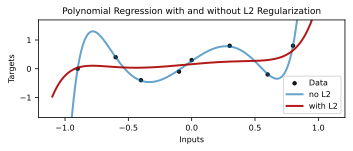

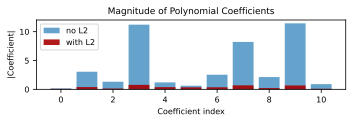

In [8]:
# Toy PyTorch example: Weight decay tames a high-degree polynomial fit
torch.manual_seed(0)

# Tiny synthetic dataset (N=8 points)
x = torch.tensor([-0.9, -0.6, -0.4, -0.1, 0.0, 0.3, 0.6, 0.8]).unsqueeze(1)  # inputs
y = torch.tensor([ 0.0,  0.4, -0.4, -0.1, 0.3, 0.8, -0.2, 0.8]).unsqueeze(1) # targets

# Polynomial feature expansion
D = 10                                             # polynomial degree
# Design matrix: each row is [1, x, x^2, ..., x^D]
X = torch.cat([x**k for k in range(D+1)], dim=1)   # shape (N, D+1)

# Linear regression model on polynomial features
def make_model(in_dim):
    return nn.Linear(in_dim, 1, bias=True)

def train(model, X, y, weight_decay=0.0, epochs=500, lr=0.1):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)    
    loss_fn = nn.MSELoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(X), y)  # fit polynomial to data
        loss.backward()
        opt.step()
    return model

# Train without weight decay: risk of large, unstable coefficients
model_no_wd = train(make_model(D+1), X, y, weight_decay=0.0)

# Train with weight decay: coefficients shrink toward 0 (smoother fit)
model_with_wd = train(make_model(D+1), X, y, weight_decay=0.01)

# Visualization
plot_regression_predictions(x, y, model_no_wd, model_with_wd, D) # compare fits
plot_regression_coefficients(model_no_wd, model_with_wd)         # compare coeffs

<a id="regularization_dropout"></a>
### Dropout

Among regularization methods, **dropout** acts in a different place than weight decay. Rather than directly shrinking parameter values during optimization (as weight decay does), it operates **inside** the network while training: a random fraction of intermediate activations is set to zero. At each step, every unit is independently dropped with probability $p$, so the remaining units must carry the prediction and the model cannot rely too heavily on any single pathway.

Why does this help? One common cause of overfitting is **co-adaptation**: several hidden units begin to depend on one another to closely match patterns and random details in the training set that are not essential or representative of the underlying data. During training, dropout makes each unit **unreliable** by removing it with probability $p$, repeatedly interrupting these dependencies. To keep the loss low, the network spreads information across many units and learns features that are useful on their own or in many combinations. As a result, it learns **redundant** and more **robust** representations. In practice, this leads to smoother decision boundaries and better generalization to new data, even if the training loss seems to be more unstable and slightly higher.

During **validation and testing**, dropout is **disabled**. Predictions should be **deterministic** and reproducible, and the network should use all available information rather than randomly removing parts of it. Applying dropout at test time would make outputs vary from one forward pass to another, making evaluation and prediction inconsistent. However, simply turning dropout off changes the average activation level at that stage of the network: since no units are dropped, the total output of a layer would be higher at test time than during training.

To avoid this mismatch, PyTorch and most frameworks apply what is sometimes called **inverted dropout**. During training, each unit is kept with probability $(1-p)$, and when it is kept, its activation is multiplied by $1/(1-p)$. This scales up the remaining activations so that the expected activation magnitude stays roughly the same as if no dropout had been applied. Thanks to this scaling, the average activation level during training matches that during inference, where dropout is turned off and no scaling is applied. The effect of inverted dropout is illustrated below using PyTorch's `nn.Dropout`:

In [9]:
# PyTorch example: Inverted dropout
torch.manual_seed(0)

x = torch.arange(1, 6, dtype=torch.float32)
model = nn.Dropout(p=0.5)

print(f"{'Input tensor x:':<42} {x}")

model.train()
# the remaining activations will be rescaled by 1/(1-0.5)=2
print(f"{'Tensor after dropout (p=0.5, train mode):':<42} {model(x)}")  

model.eval()
# no dropout in evaluation mode
print(f"{'Tensor after dropout (p=0.5, eval mode):':<42} {model(x)}")

Input tensor x:                            tensor([1., 2., 3., 4., 5.])
Tensor after dropout (p=0.5, train mode):  tensor([ 2.,  0.,  0.,  8., 10.])
Tensor after dropout (p=0.5, eval mode):   tensor([1., 2., 3., 4., 5.])


No matter which activation function is used (ReLU, sigmoid, tanh, or any other), the logic of inverted dropout is the same: when some activations are removed, the ones that remain are **scaled up** by a factor of $1/(1-p)$, where $p$ is the drop probability. This scaling keeps the **mean activation level** during training roughly the same as it would be without dropout, so the network sees comparable average magnitudes at training and inference. What does change is the **variance**: with ReLU, dropout often leads to sparser outputs and larger variations, because ReLU can produce very large values. With bounded activations like sigmoid or tanh, the outputs stay within a fixed range, so the fluctuations caused by dropout remain much smaller. In all cases, dropout increases variability during training, forcing the network to develop more robust, distributed representations rather than depending on any single unit.

This also clarifies **where** to place dropout and **what** to expect from it in practice. The standard convention is to apply dropout **after** the activation, for example <code>Linear &rarr; ReLU &rarr; Dropout</code>. In fact, ReLU is a special case where applying dropout before or after the activation is mathematically equivalent because ReLU and the dropout procedure commute. However, the order matters for other activation functions, such as sigmoid or tanh, or when dropout interacts with layers that depend on pre-activation statistics (e.g., BatchNorm). Dropout should also be avoided in the final output or logit layer, since predictions themselves should remain stable.

The dropout probability $p$ is a tunable hyperparameter: if it is too small, dropout has little effect; if it is too large, the model may underfit. Despite its simplicity, dropout is considered a standard and widely used regularization method. It is easy to apply, works across many architectures, and often improves generalization, particularly in large fully connected layers. In practice, training with dropout shows a few characteristic patterns:

* Training loss is usually **higher** and loss curves appear **noisier** (by design).  
* Validation and test performance are often **better**, especially when the model is large relative to the dataset or inputs contain noise.  
* Learned decision boundaries tend to be **smoother** and **more reliable**.

To see these effects in practice, we look at a simple two-hidden-layer MLP trained both **with** and **without** dropout on the same 2D classification task. When the inputs are **clean**, both models learn reasonable decision boundaries. As we gradually **add noise**, however, a clear difference appears: the model **without dropout** starts to overfit, its decision boundary becomes jagged, and although its training loss keeps decreasing, its accuracy on unseen data from the same distribution is likely worse. In contrast, the model **with dropout** stays more conservative: its decision boundary is smoother and changes less with the noise, which in this setting leads to better generalization to new, unseen samples.

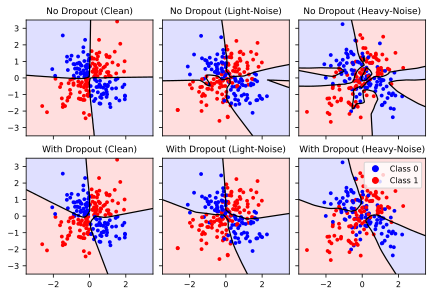

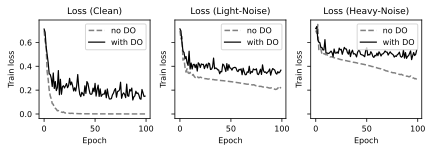

In [10]:
# Toy PyTorch example: Using Dropout
torch.manual_seed(0)

# Toy data: 2D features drawn i.i.d. from N(0, I)
N = 200
X = torch.randn(N, 2)
# Binary labels: class=1 if x1*x2 > 0 (checkerboard)
y = (X[:, 0] * X[:, 1] > 0).float().unsqueeze(1)

# Build three feature sets: same labels (from X), increasing input noise
sigma_light, sigma_heavy = 0.25, 0.50
X_0 = X
X_1 = X + sigma_light * torch.randn_like(X)
X_2 = X + sigma_heavy * torch.randn_like(X)
cases = [
    ("Clean",       X_0),
    ("Light-Noise", X_1),
    ("Heavy-Noise", X_2),
]

# Simple feedforward network (single logit; optional dropout)
class SimpleNet(nn.Module):
    def __init__(self, use_dropout=False, p=0.5, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=p) if use_dropout else nn.Identity(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=p) if use_dropout else nn.Identity(),
            nn.Linear(hidden_dim, 1)  # single logit
        )
    def forward(self, x):
        return self.net(x)  # (N,1)

# Training loop (logistic regression)
def train_model(X, y, use_dropout, epochs=100, lr=0.05, p=0.5, seed=0):
    # Fix random initialization so differences come only from dropout
    # NOTE: lr=0.05 is high for Adam; if training is jittery, try lr=0.01 or p=0.3
    torch.manual_seed(seed)  
    model = SimpleNet(use_dropout=use_dropout, p=p)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    losses = []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        logits = model(X)
        loss = loss_fn(logits, y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return model, losses

# Experiment: columns = cases (clean -> heavy noise), rows = no DO / with DO
epochs = 100
num_cols = len(cases)
fig, axs = plt.subplots(2, num_cols, figsize=(5.9, 4),
                        constrained_layout=True, sharex=True, sharey=True)

xlim, ylim = (-3.5, 3.5), (-3.5, 3.5)
all_losses = []  # list of (case_name, 2 x epochs array of losses)
for col, (case_name, X) in enumerate(cases):
    model_no_do, loss_no_do     = train_model(X, y, use_dropout=False, epochs=epochs)
    model_with_do, loss_with_do = train_model(X, y, use_dropout=True,  epochs=epochs)

    axs[0, col].set_title(case_name, fontsize=10)
    plot_data_boundary(
        axs[0, col], model_no_do, X, y,
        f"No Dropout ({case_name})", xlim=xlim, ylim=ylim
    )
    plot_data_boundary(
        axs[1, col], model_with_do, X, y,
        f"With Dropout ({case_name})", xlim=xlim, ylim=ylim,
        add_legend=(col == num_cols - 1)
    )

    all_losses.append((case_name, np.vstack([loss_no_do, loss_with_do])))
plt.show()

# Loss curves (single row; one axis per case)
fig, axs = plt.subplots(1, num_cols, figsize=(5.9, 2), 
                        constrained_layout=True, sharey=True)
for i, (case_name, losses) in enumerate(all_losses):
    plot_loss_curves(losses, epochs=epochs, labels=("no DO", "with DO"), ax=axs[i])
    axs[i].set_title(f"Loss ({case_name})", fontsize=9)
plt.show()

<a id="custom_functions"></a>
## Custom Functions in PyTorch

So far, we have worked with **built-in components**: standard modules such as linear layers and convolutions, predefined optimizers like SGD, and common loss functions such as mean squared error or cross-entropy. These tools already cover a wide range of problems and are enough to build and train many useful models. Yet one of PyTorch's most powerful features is that we are **not restricted** to this predefined set. For any **differentiable** operation applied to a tensor, PyTorch's `autograd` automatically tracks how results are computed. This means that any function we define using standard tensor operations can seamlessly become part of training: gradients will be computed, parameters will be updated, and our custom design will behave just like a built-in. In other words, the same simple building blocks used inside PyTorch itself are available to us.

This flexibility is more than a technical feature. It reflects PyTorch's **open design**. In PyTorch, models are not black boxes with only a few parts that can be swapped. We have the freedom to adapt objectives, transformations, and layers to the needs of our task. Whether it is designing a loss that values correlation over scale or introducing a transformation that encodes domain knowledge, PyTorch gives us the tools to turn such ideas into practice.

In this way, PCPT comes full circle. What began with the basics of tensors and automatic differentiation ends with the realization that these same building blocks can be combined in flexible and creative ways. By mastering the essentials, we have learned not only how to use PyTorch but also how to adapt it. This provides a foundation for our own explorations, projects, and research.

To make this flexibility concrete, we end with a short look at **custom loss functions**, some of which go beyond the built-ins. Three small examples:

**L1 loss**: Measures the average absolute difference between predictions and targets. It is more robust to outliers than MSE because large errors are not squared, and its constant-sized gradients encourage a median-like fit. This makes it suitable when errors may be heavy-tailed or when reduced sensitivity to spikes is desired. While this loss is already implemented by PyTorch’s `nn.L1Loss`, we use it here as an example to show how simple custom loss definitions can be written.

* **Correlation loss**: Measures how well prediction and target **align in shape** after removing differences in mean and scale (for example, via cosine similarity on zero-mean, unit-norm signals). It is useful when the overall pattern matters more than the absolute level, as in many audio and sensor applications.

* **Spectral loss**: Compares **magnitude spectra** obtained from a Fast Fourier Transform (FFT) instead of working directly on the raw time-domain samples. This focuses the loss on matching the **frequency content** and is largely insensitive to phase differences or small time shifts. It is a good choice when preserving harmonic structure is more important than aligning the waveform perfectly sample by sample.

The code below implements all three losses and applies them to a small set of related signals (`base`, `spiky`, `scaled`, `offset`, `shifted`, `reversed`). First, it overlays the signals in one plot; then it computes **pairwise** distances under each loss and shows them as color-coded matrices, so you can see how each loss emphasizes different aspects (amplitude, shape, or spectrum).

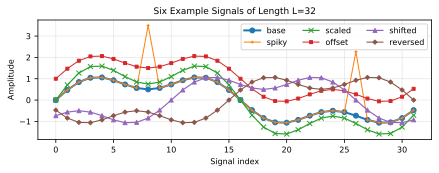

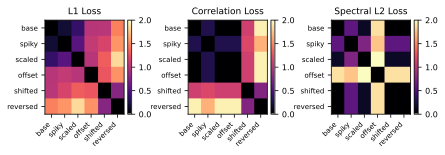

In [11]:
# Loss functions
def l1_loss(y_pred, y_true):
    return torch.mean(torch.abs(y_pred - y_true))

def corr_loss(y_pred, y_true, eps=1e-8):
    yp = y_pred - y_pred.mean()
    yt = y_true - y_true.mean()
    yp = yp / (yp.norm() + eps)
    yt = yt / (yt.norm() + eps)
    corr = torch.sum(yp * yt)   
    return 1.0 - corr           # convert correlation to a loss

def spectral_l2_fft(y_pred, y_target, n_fft=None):
    if n_fft is None: n_fft = y_pred.shape[-1]
    Mp = torch.fft.rfft(y_pred, n=n_fft, dim=-1, norm="ortho").abs()
    Mt = torch.fft.rfft(y_target, n=n_fft, dim=-1, norm="ortho").abs()
    return ((Mp - Mt)**2).mean()

# Build short related signals
L = 32
t = torch.arange(L) / L
pi = torch.pi
x_base     = 1 * torch.sin(2 * pi * 1 * t) + 0.5 * torch.sin(2 * pi * 3 * t)
x_spiky    = x_base.clone(); x_spiky[8]  += 3.0; x_spiky[26] += 3.0
x_scaled   = 1.5 * x_base
x_offset   = x_base + 1.0
x_shifted  = torch.roll(x_base, shifts=10)
x_reversed = x_base.flip(0)

signals = {
    "base":      x_base,     # reference: two sinusoids
    "spiky":     x_spiky,    # spikes at index 8 and index 26
    "scaled":    x_scaled,   # scale change
    "offset":    x_offset,   # mean offset
    "shifted":   x_shifted,  # circular shift (phase change)
    "reversed":  x_reversed, # time reversal (phase change) 
}

# Compute the loss matrix M
def compute_loss_matrix(signals_dict, loss_fn):
    """
    Returns:
        M:  N times N matrix M, where M[i, j] = loss_fn(sig_i, sig_j)
    """
    X = list(signals_dict.values()) # list of all signal tensors
    num_signals = len(X)                      # number of signals
    M = torch.zeros(num_signals, num_signals, dtype=torch.float32)
    with torch.no_grad():
        for i in range(num_signals):
            for j in range(num_signals):
                M[i, j] = loss_fn(X[i], X[j]).float()
    return M

# Compute loss matrices for three losses
M_l1   = compute_loss_matrix(signals, l1_loss)
M_corr = compute_loss_matrix(signals, corr_loss)
M_sp   = compute_loss_matrix(signals, spectral_l2_fft)

# Plot signals and loss matrices
plot_six_signals(signals, L)

fig, axs = plt.subplots(1, 3, figsize=(6.7, 1.7), gridspec_kw={'wspace': 0.65}, 
                        constrained_layout=False)
names = signals.keys()
plot_loss_matrix(names, M_l1,  axs[0], title="L1 Loss")
plot_loss_matrix(names, M_corr, axs[1], title="Correlation Loss")
plot_loss_matrix(names, M_sp,   axs[2], title="Spectral L2 Loss")
for ax in axs:
    ax.tick_params(labelsize=7)
plt.show()

<a id='exercise_bn_running_stats'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 1: Batch Normalization Running Statistics</strong><br>

<p style="color:#006064;">
This exercise explores how <code>BatchNorm</code> updates its <strong>running mean</strong> and <strong>running variance</strong> under different settings. To this end, we consider a model defined as <code>model = nn.BatchNorm1d(num_features, momentum=momentum, affine=False)</code>, where:
</p>
<ul style="color:#006064;">
  <li><code>num_features</code> is the feature dimension (here we use <code>num_features = 1</code>).</li>
  <li><code>momentum</code> controls how quickly the running statistics adapt to new batches.</li>
  <li><code>affine=False</code> means <code>BatchNorm</code> does not learn a scale (<code>gamma</code>) or shift (<code>beta</code>), i.e., the layer outputs only the normalized activations, without any trainable post-scaling. This way, we isolate the effect of the normalization itself.</li>
</ul>
<p style="color:#006064;">
The running statistics are stored in <code>model.running_mean</code> and <code>model.running_var</code>. They are non-trainable buffers and are updated every time the model processes a mini-batch in training mode.  
</p>

<ul style="color:#006064;"> 
  <li>Create a dataset with <code>N</code> samples and one feature, stored in a matrix <code>X</code> of shape <code>[N, 1]</code> (e.g., <code>N=200</code>). Build a <code>DataLoader</code> with batch size <code>B</code>, which splits <code>X</code> into <code>N / B</code> mini-batches.</li>
  <li>Iterate for a fixed number of epochs (e.g., <code>30</code>). In each epoch, process all mini-batches by calling <code>model(xb)</code> for each batch <code>xb</code>, and record the values of <code>running_mean</code> and <code>running_var</code> after each epoch.</li>
  <li>Plot the curves of running mean and running variance over epochs.</li>
  <li>Repeat this experiment for different datasets <code>X</code> (e.g., following a unimodal Gaussian distribution or a bimodal mixture distribution).</li>
  <li>Repeat again for different momentum parameters (e.g., <code>0.01</code>, <code>0.04</code>, <code>0.1</code>) and for different batch sizes (e.g., <code>B=4</code>, <code>B=16</code>, <code>B=64</code>).</li>
</ul>

<p style="color:#006064;">
Finally, discuss the results, in particular the trade-off between momentum (how much weight is given to new batch statistics) and batch size (how noisy or smooth the per-batch statistics are).
</p>
</div>

In [12]:
# Your Solution

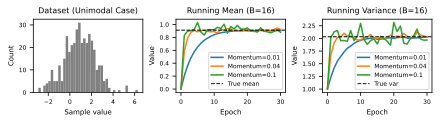

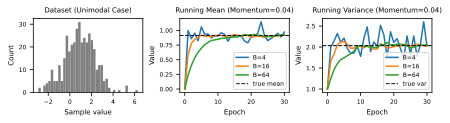

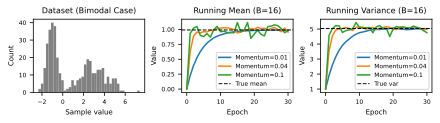

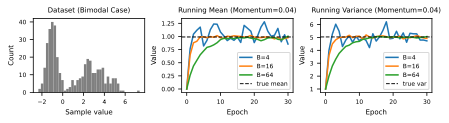

* With small batch sizes, the per-batch mean and variance fluctuate strongly,
  so the running statistics look zigzaggy.
* At the same time, more batches per epoch mean more updates, so the statistics
  adapt faster even with the same momentum.
* Large batches give smoother but fewer updates, making convergence steadier but
  slower.
* In practice, BatchNorm works best with reasonably large batches that balance
  stability and adaptability.


In [13]:
# Run and show output of the reference solution
exercise_bn_running_stats()

<a id='exercise_dropout_masks'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 2: Visualizing Dropout Masks and Inverted Scaling</strong><br>

<p style="color:#006064;">
This exercise shows how <strong>dropout</strong> randomly zeros activations and how <strong>inverted dropout</strong> scales the surviving values by <code>1/(1-p)</code> so the expected magnitude stays similar.
</p>

<ul style="color:#006064;">
  <li>Create a small activation matrix <code>X</code> of dimension <code>N &times; D</code> with <code>N</code> being the number of samples and <code>D</code> being the feature dimension.</li>
  <li>Apply dropout with several probabilities, e.g., <code>p = 0.25</code>, <code>p = 0.5</code>, and <code>p = 0.75</code>. To this end, create a layer <code>drop = nn.Dropout(p=p)</code>.</li>
  <li>Recover the exact <code>0/1</code> dropout mask in a way that does <strong>not</strong> depend on the values of <code>X</code>, e.g., via <code>mask = drop(torch.ones_like(X))</code>.</li>
  <li>For each <code>p</code>, plot the input <code>X</code>, the dropout mask, and the output after applying the dropout mask to <code>X</code>.</li>
</ul>
</div>

In [14]:
# Your Solution

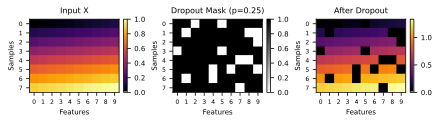

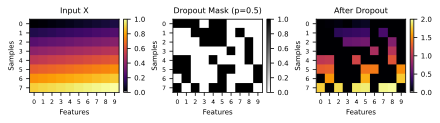

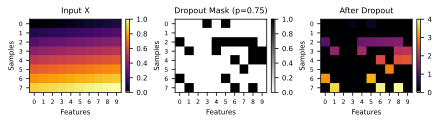

In [15]:
# Run and show output of the reference solution
exercise_dropout_masks()

<a id='exercise_custom_losses'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064;">Exercise 3: Learning a Convolution Kernel with Different Loss Functions</strong><br>

<p style="color:#006064;">
In this exercise, we study how different loss functions shape the learning of a 1D convolution kernel that maps an input signal to a given target signal. More specifically, the general task is as follows: Given an input signal <code>x</code> and a target signal <code>y_target</code>, both of length <code>L</code>, train a 1D convolution kernel <code>h</code> of length <code>K</code> such that <code>y_est = F.conv1d(x, h, padding="same")</code> is close to <code>y_target</code>. The quality of the learned kernel and the resulting output depends strongly on the choice of the <strong>loss function</strong>. Besides the standard <code>F.mse_loss</code>, consider the custom loss functions <code>l1_loss</code>, <code>corr_loss</code>, and <code>spectral_l2_fft</code> defined above. Now do the following experiment:
</p>

<ul style="color:#006064;">
<li>Create different <code>(x, y_target)</code> pairs and train a convolution kernel <code>h</code> using each loss function.</li> 
<li>For each pair, run the optimization and visualize:</li> 
    <ul style="color:#006064;">
        <li>the loss curve,</li> 
        <li>the input signal <code>x</code>,</li> 
        <li>the learned kernel <code>h</code> (and true kernel <code>h_true</code> if available),</li> 
        <li>the estimated output <code>y_est</code> versus the target output <code>y_target</code>.</li> 
    </ul>
<li>Compare how the choice of loss influences the learned kernel and output quality.</li> 
</ul> 

<p style="color:#006064;">
For these experiments you may use the following example setups:  
</p>

<ul style="color:#006064;">
<li><strong>Example 1</strong>: Let <code>x</code> be random noise and <code>y_target</code> a sinusoid. In this case, the kernel <code>h</code> must transform noise into a clean sinusoidal output (here use <code>K = L</code>).</li> 
<li><strong>Example 2</strong>: Let <code>x</code> be random noise and create a random convolution kernel <code>h_true</code>. Generate <code>y_target</code> by convolving <code>x</code> with <code>h_true</code> (and optionally add noise). The task is then to recover <code>h_true</code> by training with different losses (here use <code>K &lt; L</code>).</li> 
</ul> 

<p style="color:#006064;">
<strong>Discussion:</strong> Which losses recover <code>h</code> more faithfully in the time domain vs. the frequency domain? Why are there differences in the estimated <code>y_est</code>, in particular when using <code>corr_loss</code> and <code>spectral_l2_fft</code>?  
</p>
</div>

In [16]:
# Your Solution


Example 1: random input, sinusoidal output, no true kernel


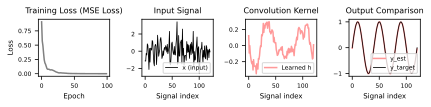

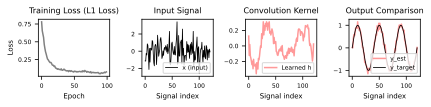

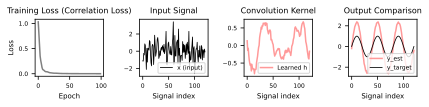

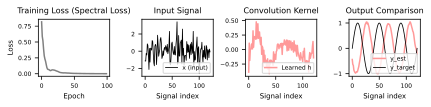


Example 2: random input, random kernel, output via convolution plus noise


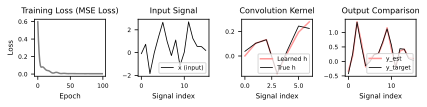

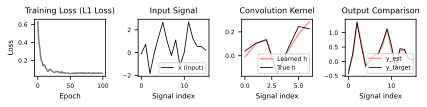

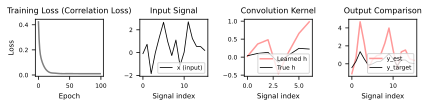

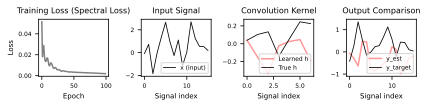

In [17]:
# Run and show output of the reference solution
exercise_custom_losses()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>